# 📊 EDA — Empleo por Tipo de Actividad Económica
**Fuente:** `e_tipo_actividad.csv`  
**Descripción:** Empleo dependiente privado mensual en Lima Metropolitana por sector de actividad económica: Agropecuario y Pesca, Manufactura, Comercio, Construcción, Minería y Canteras, Servicios. Período 2015–2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({'figure.dpi': 130})
sns.set_theme(style='whitegrid', palette='muted')

SECTORES = ['agropecuario_pesca','manufactura','comercio','construccion','mineria_canteras','servicios']
COLORES = ['#27ae60','#e74c3c','#f39c12','#8e44ad','#2c3e50','#2980b9']
ETIQUETAS = ['Agropecuario\ny Pesca','Manufactura','Comercio','Construcción','Minería\ny Canteras','Servicios']
MES_ORDEN = {'ENE.':1,'FEB.':2,'MAR.':3,'ABR.':4,'MAY.':5,'JUN.':6,
             'JUL.':7,'AGO.':8,'SET.':9,'OCT.':10,'NOV.':11,'DIC.':12}
MESES_ETQ = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Set','Oct','Nov','Dic']
print('OK ✓')

OK ✓


## 1. Carga y Limpieza

In [2]:
df = pd.read_csv('e_tipo_actividad.csv', sep=';', encoding='utf-8', on_bad_lines='skip')
df.columns = df.columns.str.replace('\n', ' ', regex=False).str.strip()
df.columns = ['anio','mes','agropecuario_pesca','manufactura','comercio',
              'construccion','mineria_canteras','servicios','no_especificado']

for col in SECTORES + ['no_especificado']:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=['servicios'], inplace=True)
df['anio'] = df['anio'].astype(int)
df['mes_num'] = df['mes'].map(MES_ORDEN)
df['fecha'] = pd.to_datetime(df['anio'].astype(str) + '-' + df['mes_num'].astype(str).str.zfill(2), format='%Y-%m')
df.sort_values('fecha', inplace=True)
df.reset_index(drop=True, inplace=True)
df['total'] = df[SECTORES].sum(axis=1)

print(f'Shape: {df.shape}')
df.head()

Shape: (133, 12)


,anio,mes,agropecuario_pesca,manufactura,comercio,construccion,mineria_canteras,servicios,no_especificado,mes_num,fecha,total
0,2015,ENE.,220237,499074,533136,216158,111319,1547500,2931,1,2015-01-01,3127424
1,2015,FEB.,201458,492879,533642,216063,111152,1560301,3016,2,2015-02-01,3115495
2,2015,MAR.,187442,491490,536425,215902,111326,1624342,3128,3,2015-03-01,3166927
3,2015,ABR.,191167,493067,536826,215775,110893,1660939,3116,4,2015-04-01,3208667
4,2015,MAY.,195467,476044,538287,219934,110004,1676276,3214,5,2015-05-01,3216012


## 2. Estadísticas Descriptivas

In [3]:
desc = df[SECTORES + ['total']].describe().round(0)
desc.index = ['Conteo','Media','Desv. Est.','Mín','Q25','Mediana','Q75','Máx']
desc

,agropecuario_pesca,manufactura,comercio,construccion,mineria_canteras,servicios,total
Conteo,133.0,133.0,133.0,133.0,133.0,133.0,133.0
Media,314410.0,516137.0,608995.0,201501.0,109310.0,1868395.0,3618747.0
Desv. Est.,87503.0,33409.0,54062.0,25064.0,9371.0,186271.0,350727.0
Mín,187151.0,413391.0,502453.0,78850.0,86636.0,1471446.0,2795659.0
Q25,247406.0,495468.0,564045.0,187267.0,103383.0,1734290.0,3351254.0
Mediana,286942.0,513138.0,591220.0,206802.0,107213.0,1841938.0,3565107.0
Q75,377263.0,534991.0,665864.0,219567.0,115804.0,2031399.0,3886991.0
Máx,535346.0,609600.0,722516.0,241098.0,132044.0,2245373.0,4463673.0


In [4]:
print('Rango:', df['fecha'].min().strftime('%b %Y'), '→', df['fecha'].max().strftime('%b %Y'))
print(f'\nParticipación promedio por sector:')
for s, etq in zip(SECTORES, ETIQUETAS):
    pct = df[s].mean() / df['total'].mean() * 100
    print(f'  {etq.replace(chr(10)," "):25s}: {pct:.1f}%')

Rango: Jan 2015 → Jan 2026

Participación promedio por sector:
  Agropecuario y Pesca     : 8.7%
  Manufactura              : 14.3%
  Comercio                 : 16.8%
  Construcción             : 5.6%
  Minería y Canteras       : 3.0%
  Servicios                : 51.6%


## 3. Serie de Tiempo por Sector

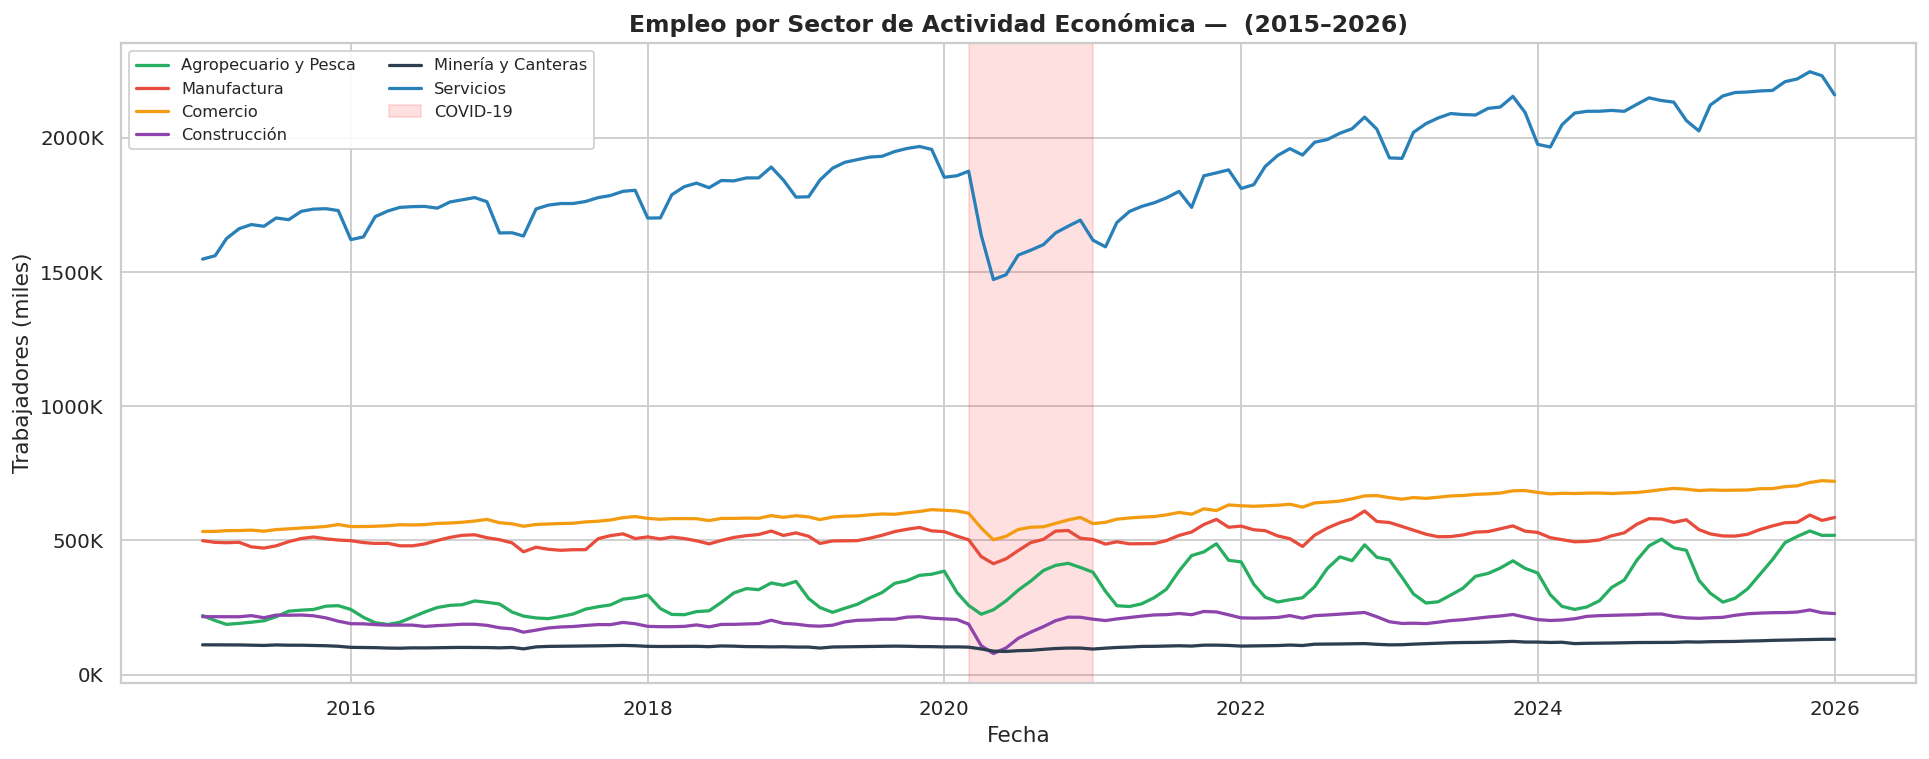

In [12]:
fig, ax = plt.subplots(figsize=(15, 6))
for sec, color, etq in zip(SECTORES, COLORES, ETIQUETAS):
    ax.plot(df['fecha'], df[sec]/1e3, label=etq.replace('\n',' '), color=color, lw=1.8)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), alpha=0.12, color='red', label='COVID-19')
ax.set_title('Empleo por Sector de Actividad Económica —  (2015–2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Trabajadores (miles)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.legend(ncol=2, framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

## 4. Promedio Anual por Sector (Barras Apiladas)

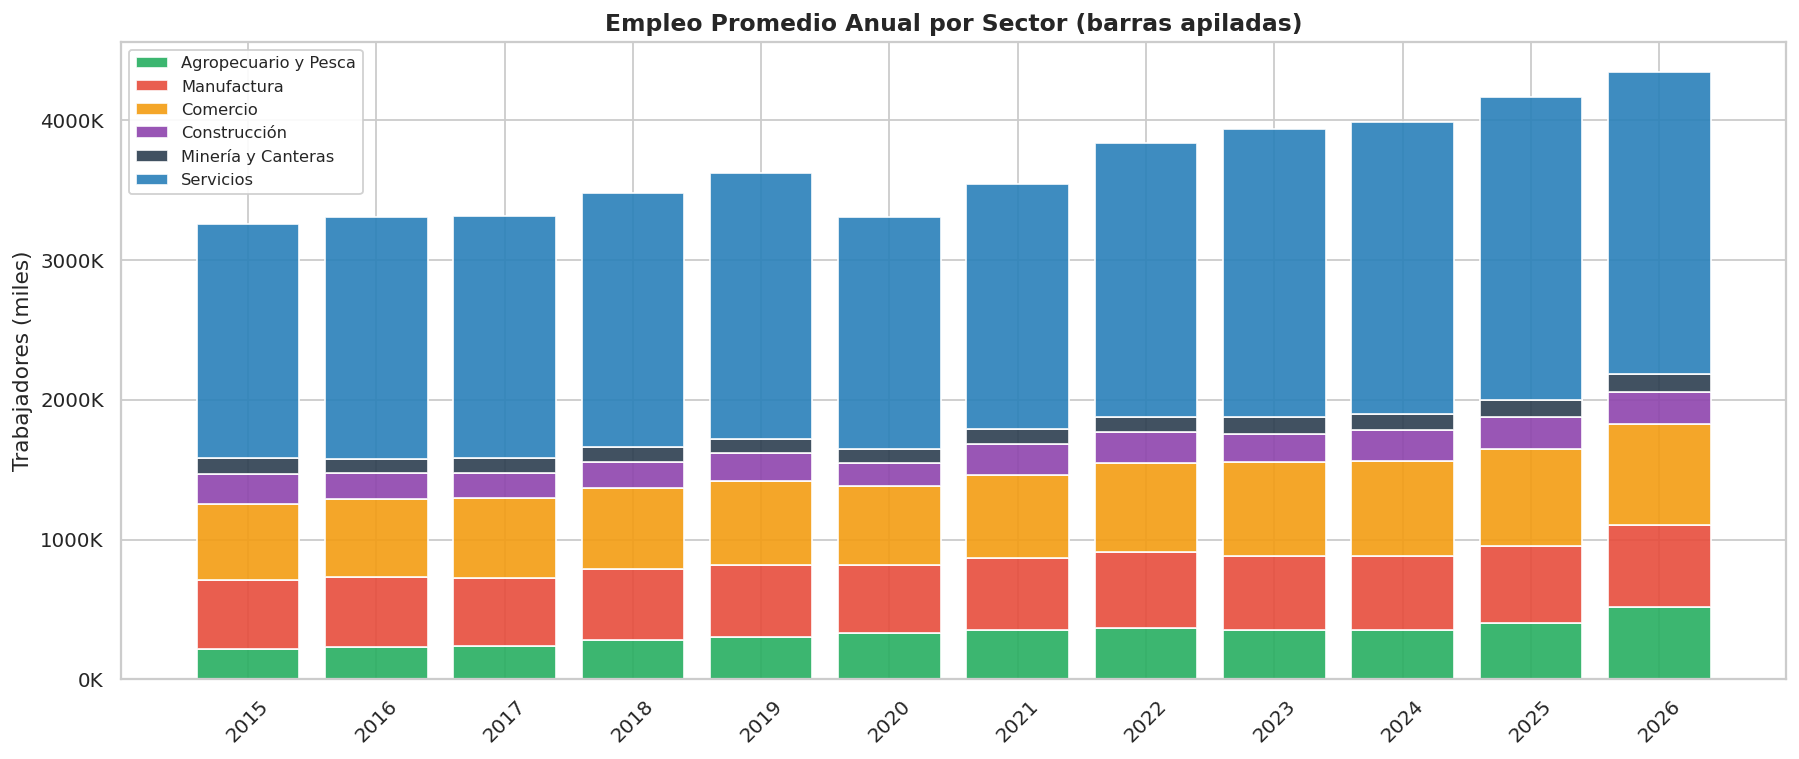

In [6]:
anual = df.groupby('anio')[SECTORES].mean()
fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(anual))
x = np.arange(len(anual))
for sec, color, etq in zip(SECTORES, COLORES, ETIQUETAS):
    vals = anual[sec].values / 1e3
    ax.bar(x, vals, bottom=bottom, label=etq.replace('\n',' '), color=color, alpha=0.9)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(anual.index.astype(int), rotation=45)
ax.set_title('Empleo Promedio Anual por Sector (barras apiladas)', fontsize=13, fontweight='bold')
ax.set_ylabel('Trabajadores (miles)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

## 5. Participación Porcentual por Sector (último año disponible)

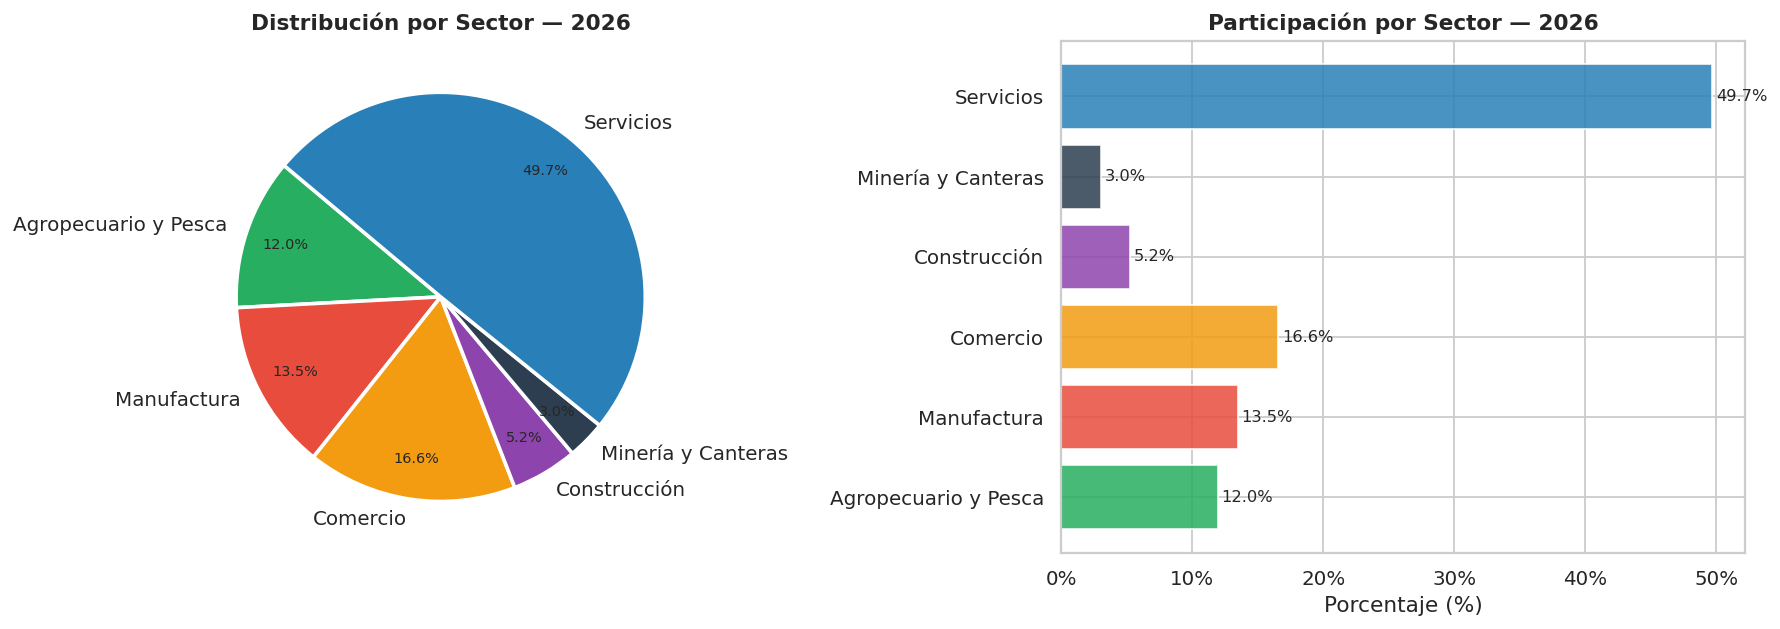

In [13]:
ultimo_anio = df['anio'].max()
df_ult = df[df['anio'] == ultimo_anio][SECTORES].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
wedges, texts, autotexts = axes[0].pie(
    df_ult.values, labels=[e.replace('\n',' ') for e in ETIQUETAS],
    colors=COLORES, autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':2}, pctdistance=0.8)
for at in autotexts:
    at.set_fontsize(8)
axes[0].set_title(f'Distribución por Sector — {ultimo_anio}', fontweight='bold')

# Barras horizontales
pct = df_ult / df_ult.sum() * 100
y_pos = range(len(SECTORES))
axes[1].barh(y_pos, pct.values, color=COLORES, alpha=0.85, edgecolor='white')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([e.replace('\n',' ') for e in ETIQUETAS])
axes[1].set_xlabel('Porcentaje (%)')
axes[1].set_title(f'Participación por Sector — {ultimo_anio}', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())
for i, v in enumerate(pct.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Estacionalidad por Sector

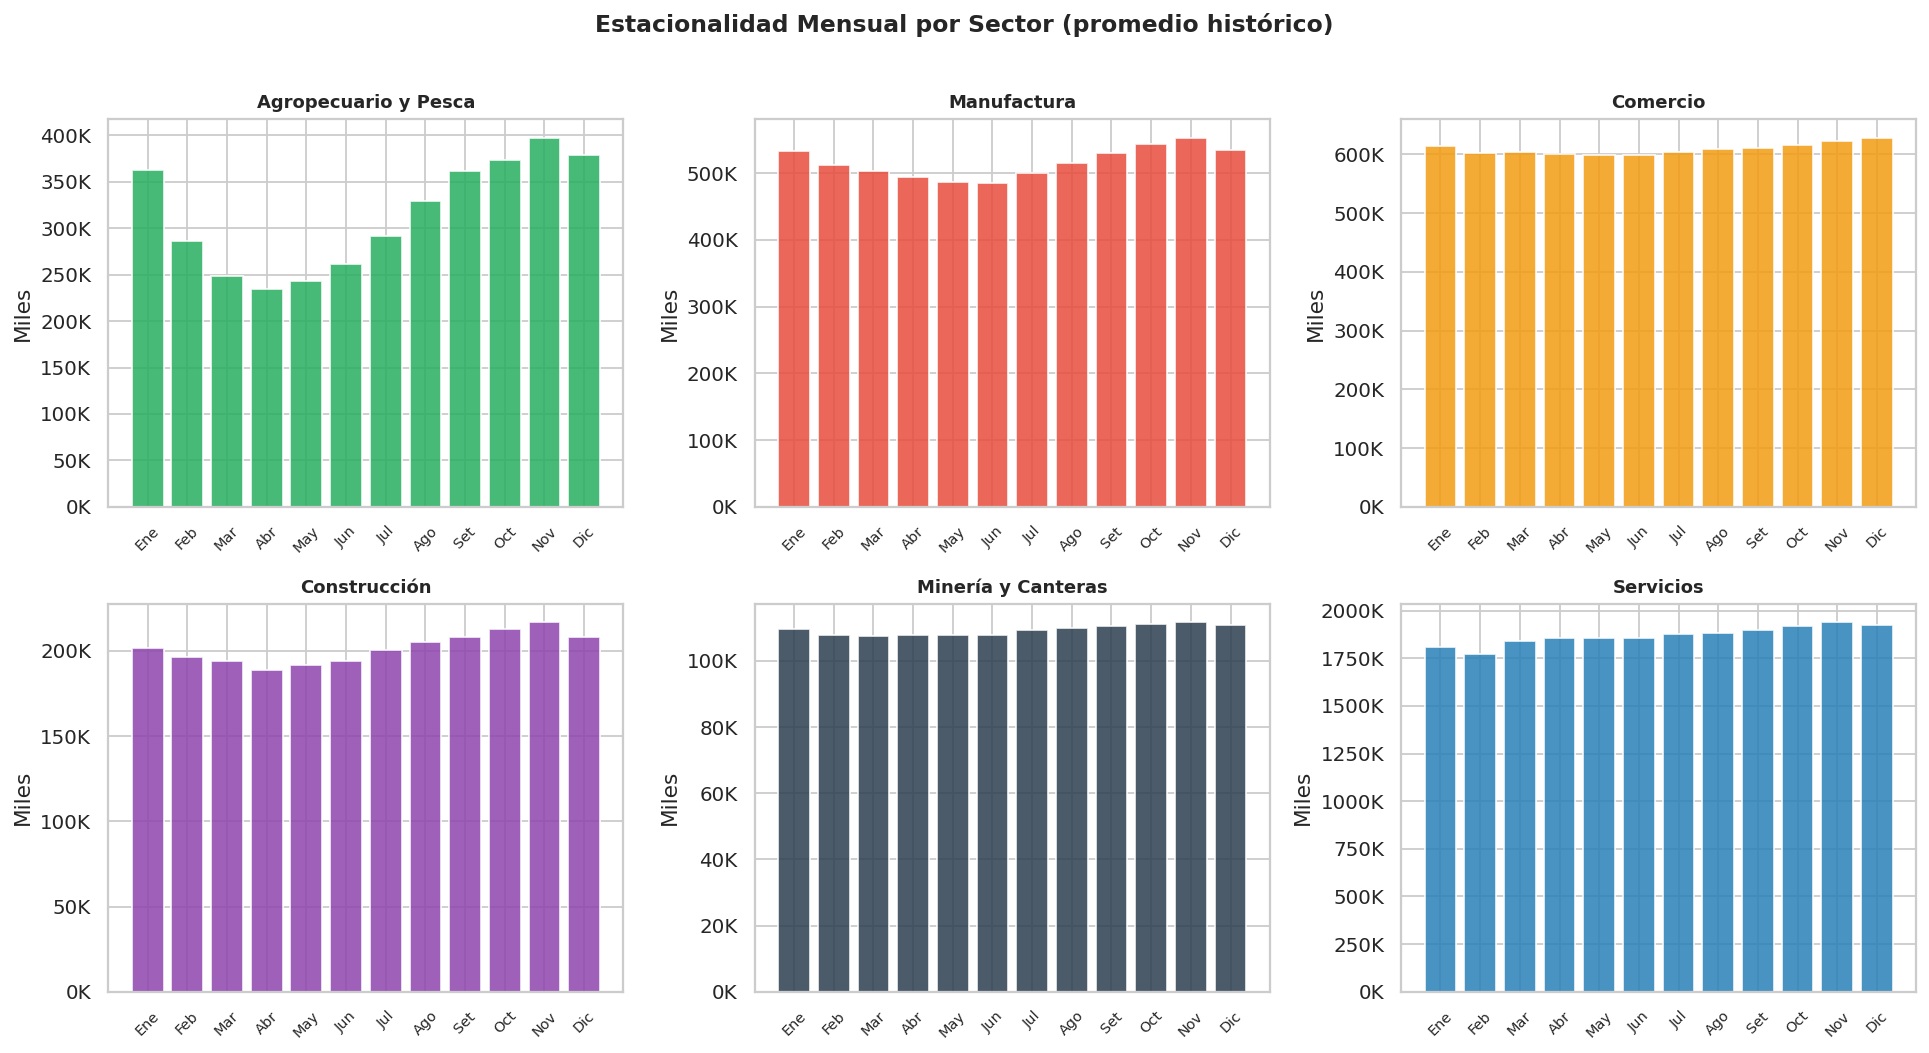

In [8]:
estac = df.groupby('mes_num')[SECTORES].mean()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, (sec, color, etq) in enumerate(zip(SECTORES, COLORES, ETIQUETAS)):
    axes[i].bar(range(1,len(estac)+1), estac[sec]/1e3, color=color, alpha=0.85)
    axes[i].set_xticks(range(1,len(estac)+1))
    axes[i].set_xticklabels(MESES_ETQ[:len(estac)], rotation=45, fontsize=8)
    axes[i].set_title(etq.replace('\n',' '), fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Miles')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
plt.suptitle('Estacionalidad Mensual por Sector (promedio histórico)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Mapa de Calor — Sector Servicios (el mayor)

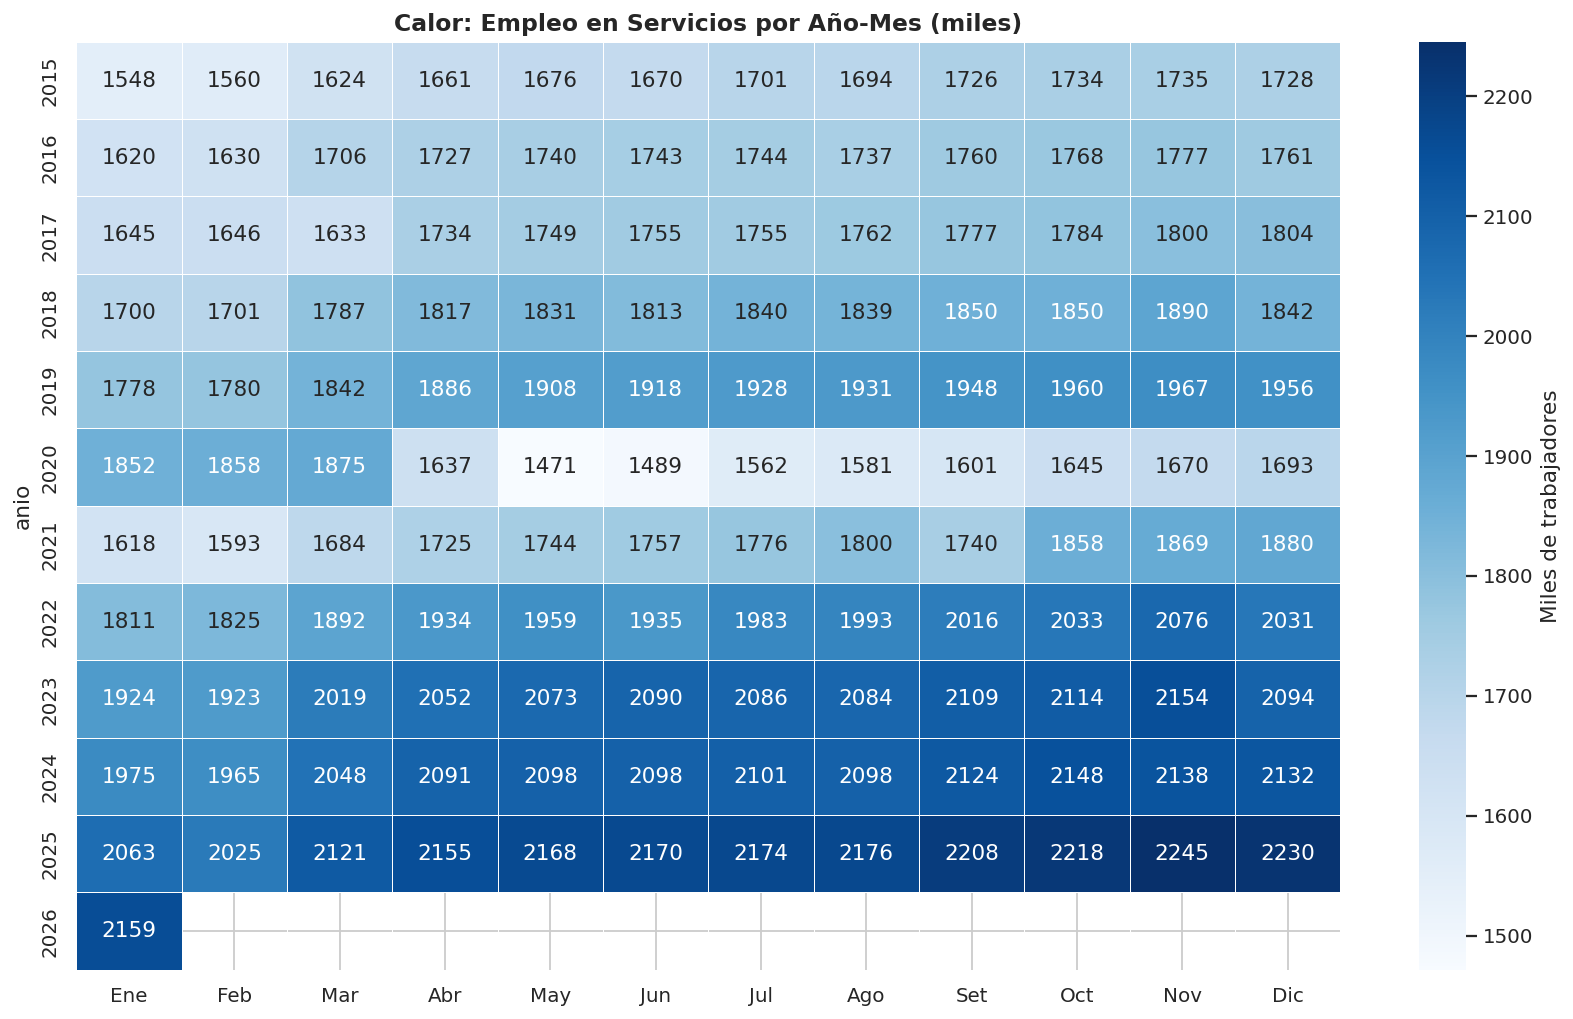

In [9]:
pivot = df.pivot_table(index='anio', columns='mes_num', values='servicios', aggfunc='mean')
pivot.columns = MESES_ETQ[:len(pivot.columns)]
fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(pivot/1e3, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Miles de trabajadores'})
ax.set_title('Calor: Empleo en Servicios por Año-Mes (miles)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Correlación entre Sectores

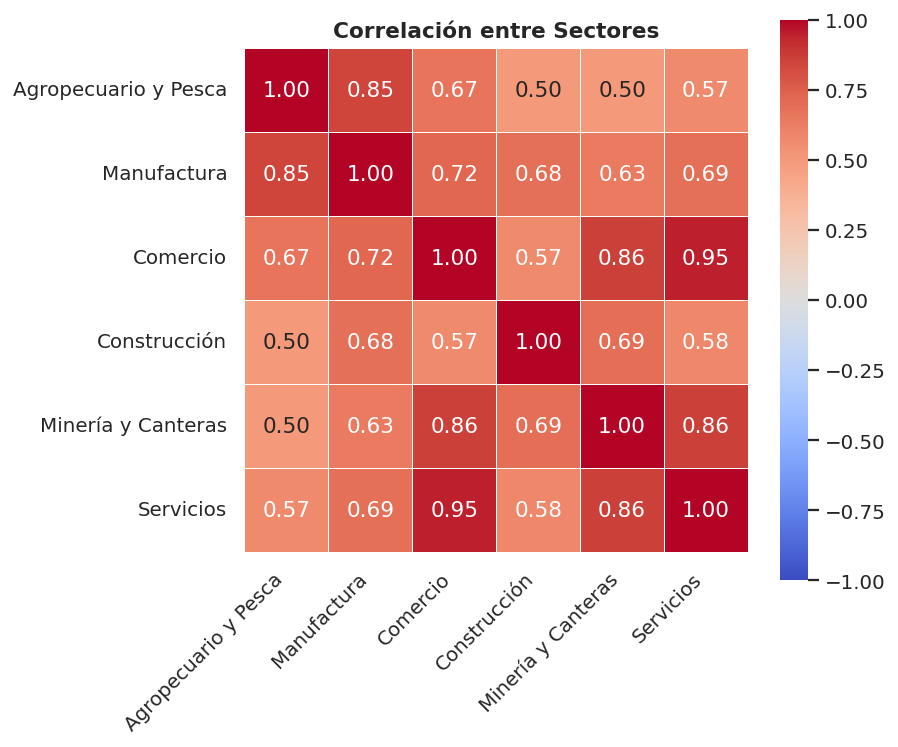

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df[SECTORES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=[e.replace('\n',' ') for e in ETIQUETAS],
            yticklabels=[e.replace('\n',' ') for e in ETIQUETAS])
ax.set_title('Correlación entre Sectores', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Impacto COVID-19 por Sector (caída May-2020 vs Feb-2020)

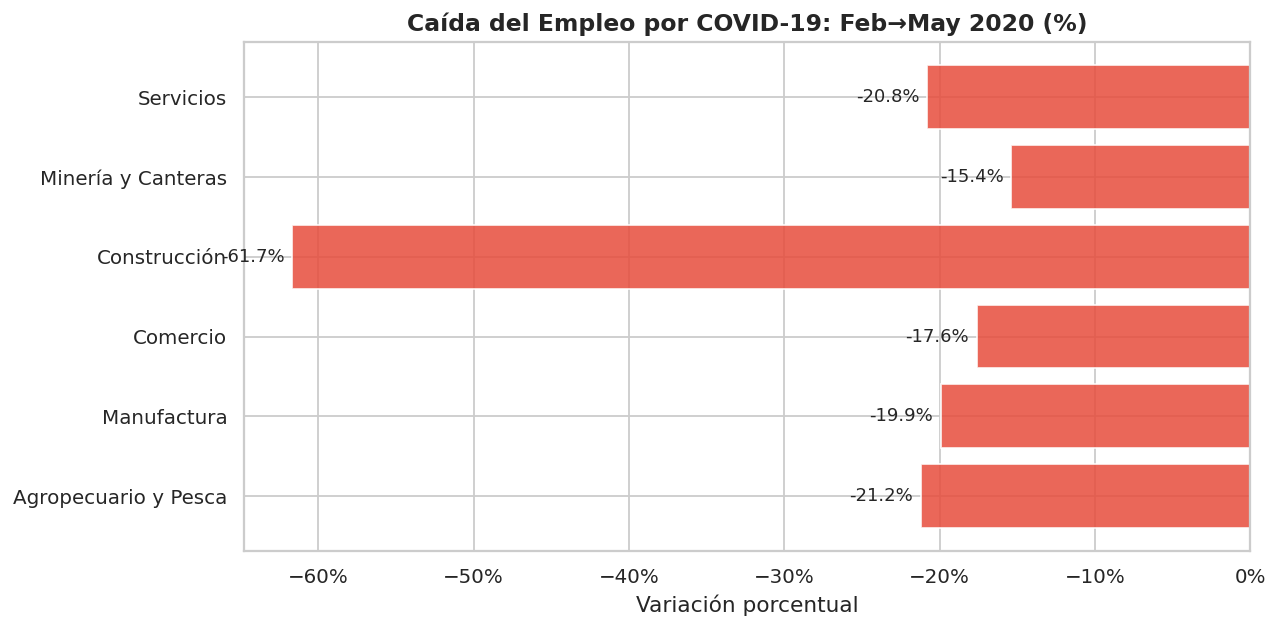

In [11]:
pre_covid = df[df['fecha'] == '2020-02-01'][SECTORES].values.flatten()
min_covid = df[df['fecha'] == '2020-05-01'][SECTORES].values.flatten()
caida_pct = (min_covid - pre_covid) / pre_covid * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#e74c3c' if v < 0 else '#27ae60' for v in caida_pct]
bars = ax.barh([e.replace('\n',' ') for e in ETIQUETAS], caida_pct, color=colors_bar, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, caida_pct):
    ax.text(val - 0.5 if val < 0 else val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='right' if val < 0 else 'left', va='center', fontsize=10)
ax.set_title('Caída del Empleo por COVID-19: Feb→May 2020 (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Variación porcentual')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

## 10. Resumen de Hallazgos

| Sector | Participación Promedio | Tendencia | COVID Impacto |
|--------|----------------------|-----------|---------------|
| Servicios | ~57% | ▲ Fuerte | Moderado |
| Comercio | ~20% | ▲ Estable | Moderado |
| Manufactura | ~17% | ▼ Leve declive | Moderado |
| Construcción | ~7% | ▲ Leve | Alto |
| Agropecuario/Pesca | ~11% | ▲ Creciente | Bajo |
| Minería | ~4% | ▼ Leve declive | Bajo |

**Observaciones clave:**
- **Servicios** domina el empleo privado con >55% de participación y crecimiento sostenido.
- **Construcción** fue el sector más golpeado por el COVID-19 (caída ~55% entre Feb-May 2020).
- **Agropecuario/Pesca** tiene alta estacionalidad (picos en AGO-SET).
- **Manufactura** muestra una ligera tendencia decreciente desde 2017.